
### Práctica 3 - Series de Fourier 

#### Presentado por: Alma Olea Barbosa - Lauren Cordero Ramos 

#### Semestre: 2026-2

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

In [ ]:
# Se definen parámetros necesarios en la construcción de las señales

f0 = 10          # frecuencia fundamental [Hz]
A = 1.0           # amplitud
P = 5             # numero de periodos a generar
fs = 2000.0       # frecuencia de muestreo [Hz]
N_per = int(fs / f0)   # muestras por periodo (200)
N = N_per * P          # numero total de muestras (1000)
t = np.arange(N) / fs  # vector de tiempo


a - Construcción de la señal cuadrada periódica 

In [20]:
def senal_cuadrada_periodica(t, f0, A):
    fase = np.round((f0 * t) % 1.0, 9)  # fase normalizada en [0, 1)
    return A * np.where(fase < 0.5, 1.0, -1.0)

b - Construcción de la señal triangular periódica 

In [21]:
def senal_triangular_periodica(t, f0, A):
    return (2 * A / np.pi) * np.arcsin(np.sin(2 * np.pi * f0 * t))

c - Gráfica de la señal cuadrada y triangular (ambas periódicas) en el dominio del tiempo 

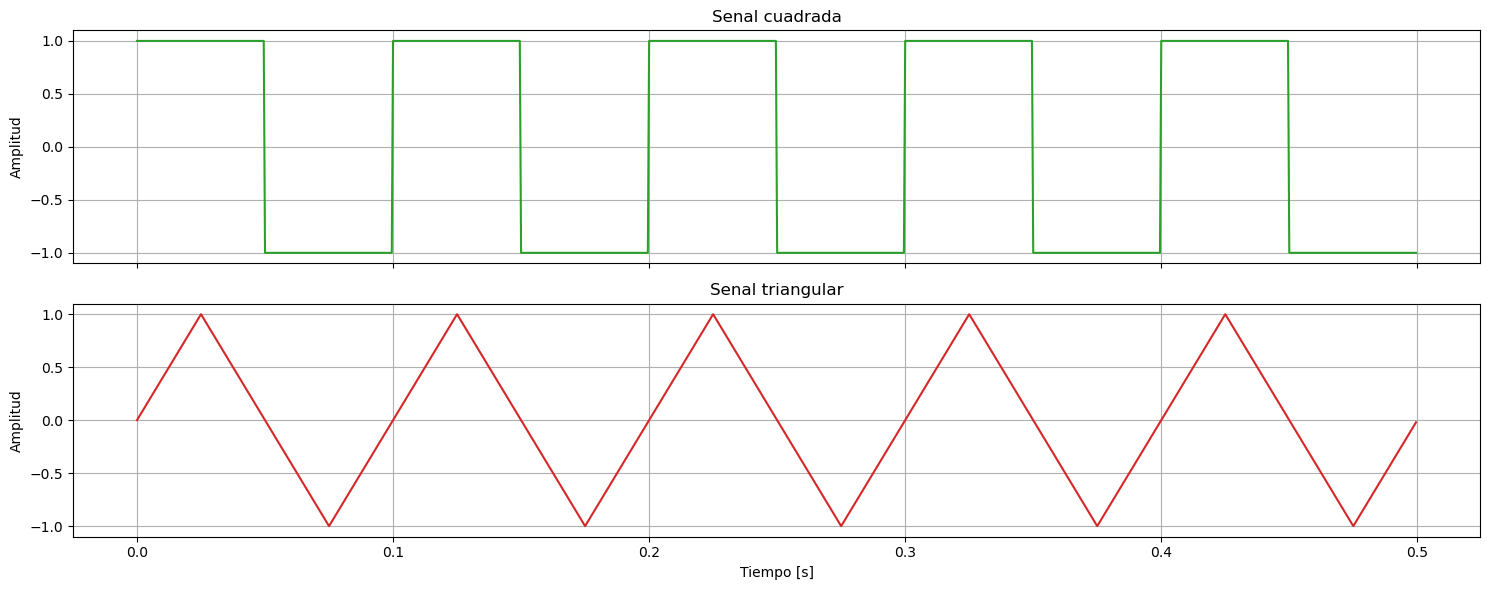

In [22]:
x_cuadrada = senal_cuadrada_periodica(t, f0, A)
x_triangular = senal_triangular_periodica(t, f0, A)

fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
ax[0].plot(t, x_cuadrada, color="tab:green")
ax[0].set_title("Senal cuadrada")
ax[1].plot(t, x_triangular, color="tab:red")
ax[1].set_title("Senal triangular")
ax[1].set_xlabel("Tiempo [s]")
for a in ax:
    a.set_ylabel("Amplitud")
    a.grid(True)

plt.tight_layout()

d - Función que recibe la señal periódica y devuelve sus coeficientes de la serie de fourier

In [23]:
#    c_k = (1/T) * integral_0^T x(t) e^{-j k w0 t} dt
#    En discreto (un periodo de N_per muestras): c_k = (1/N_per) * sum x[n] e^{-j 2 pi k n / N_per}
#    que es exactamente FFT(x)/N_per.
def coeficientes_fourier(x, muestras_por_periodo, K=None):
    """Devuelve (k, c_k) para k = -K..K a partir de UN periodo de la senal."""
    xp = np.asarray(x)[:muestras_por_periodo]
    M = len(xp)
    c = np.fft.fft(xp) / M
    k = np.fft.fftfreq(M, d=1.0 / M).astype(int)  # indices armonicos
    k = np.fft.fftshift(k)
    c = np.fft.fftshift(c)
    if K is not None:
        mask = np.abs(k) <= K
        k, c = k[mask], c[mask]
    return k, c


e - Coeficientes de la señal cuadrada y triangular 

Se muestran únicamente los coeficientes cuya magnitud supera 10⁻³. Los coeficientes restantes (k = 0 y k par) son teóricamente nulos debido a la simetría de media onda de ambas señales, y su valor numérico (~10⁻¹⁶) corresponde a error de redondeo. Además, se truncó el análisis a |k| ≤ 15, ya que estos armónicos concentran aproximadamente el 97.5 % de la potencia de la señal cuadrada y más del 99.9 % de la triangular."

In [24]:
K = 15
k_c, c_cuadrada = coeficientes_fourier(x_cuadrada, N_per, K)
k_t, c_triangular = coeficientes_fourier(x_triangular, N_per, K)


def mostrar_coeficientes(k, c, f0, titulo="", tol=1e-3):
    print(f"\nCoeficientes de Fourier - {titulo}")
    print("-" * 74)
    print(f"{'k':>4} {'f [Hz]':>9} {'Re(c_k)':>10} {'Im(c_k)':>10} "
          f"{'|c_k|':>9} {'Fase [rad]':>11} {'Fase [grados]':>14}")
    print("-" * 74)
    for ki, ci in zip(k, c):
        if abs(ci) > tol:
            fase = np.angle(ci)
            print(f"{ki:>4d} {ki * f0:>9.1f} {ci.real:>10.4f} {ci.imag:>10.4f} "
                  f"{abs(ci):>9.4f} {fase:>11.4f} {np.degrees(fase):>14.2f}")
    print("-" * 74)


mostrar_coeficientes(k_c, c_cuadrada, f0, "señal cuadrada")
mostrar_coeficientes(k_t, c_triangular, f0, "señal triangular")


Coeficientes de Fourier - señal cuadrada
--------------------------------------------------------------------------
   k    f [Hz]    Re(c_k)    Im(c_k)     |c_k|  Fase [rad]  Fase [grados]
--------------------------------------------------------------------------
 -15    -150.0     0.0100     0.0417    0.0428      1.3352          76.50
 -13    -130.0     0.0100     0.0483    0.0493      1.3666          78.30
 -11    -110.0     0.0100     0.0573    0.0582      1.3980          80.10
  -9     -90.0     0.0100     0.0703    0.0710      1.4294          81.90
  -7     -70.0     0.0100     0.0906    0.0911      1.4608          83.70
  -5     -50.0     0.0100     0.1271    0.1275      1.4923          85.50
  -3     -30.0     0.0100     0.2120    0.2123      1.5237          87.30
  -1     -10.0     0.0100     0.6366    0.6366      1.5551          89.10
   1      10.0     0.0100    -0.6366    0.6366     -1.5551         -89.10
   3      30.0     0.0100    -0.2120    0.2123     -1.5237         -

f - Función que recibe el conjunto de coeficientes de fourier

In [25]:
def espectros_fourier(c, f0=1.0, titulo="", tol=1e-8,
                      color_mag="tab:blue", color_fase="tab:red"):
    c = np.asarray(c)
    M = len(c)
    k = np.arange(M) - M // 2   # índices armonicos, que se encuentran centrados en k = 0
    f = k * f0

    mag = np.abs(c)
    fase = np.angle(c)
    fase[mag < tol] = 0.0       # la fase no tiene sentido donde |c_k| es aproximadamente 0

    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax[0].stem(f, mag, linefmt=color_mag, markerfmt="o", basefmt="k-")
    ax[0].set_ylabel("|c_k|")
    ax[0].set_title(f"Espectro de magnitud - {titulo}")

    ax[1].stem(f, fase, linefmt=color_fase, markerfmt="o", basefmt="k-")
    ax[1].set_ylabel("Fase [rad]")
    ax[1].set_xlabel("Frecuencia [Hz]" if f0 != 1.0 else "Armónico k")
    ax[1].set_title(f"Espectro de fase - {titulo}")

    # Eje de fase en múltiplos de pi
    ax[1].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax[1].set_yticklabels(["-π", "-π/2", "0", "π/2", "π"])
    ax[1].set_ylim(-np.pi * 1.1, np.pi * 1.1)

    for a in ax:
        a.grid(True)
    plt.tight_layout()

g - Espectros de magnitud y fase para la señal cuadrada y triangular

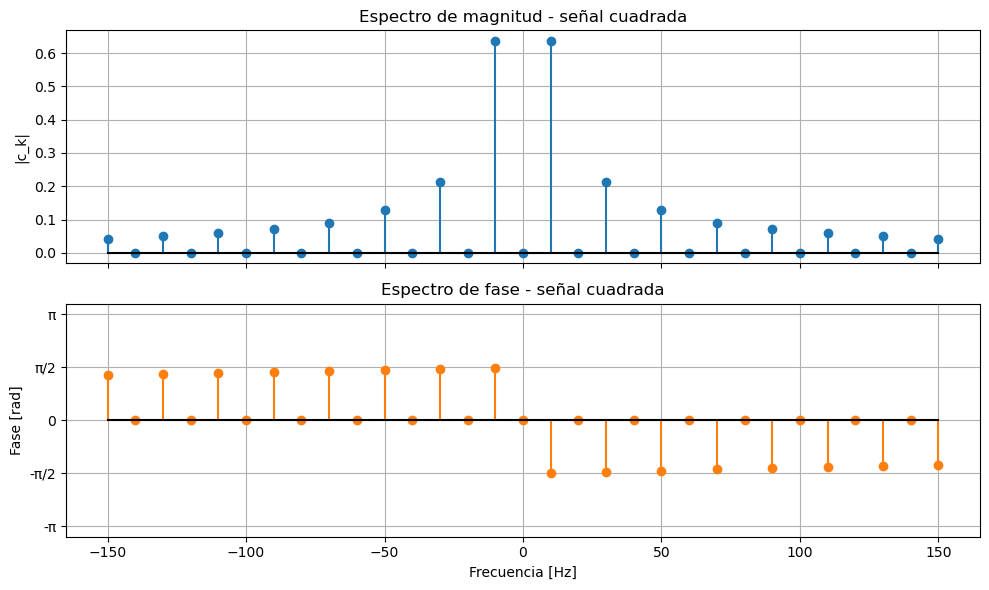

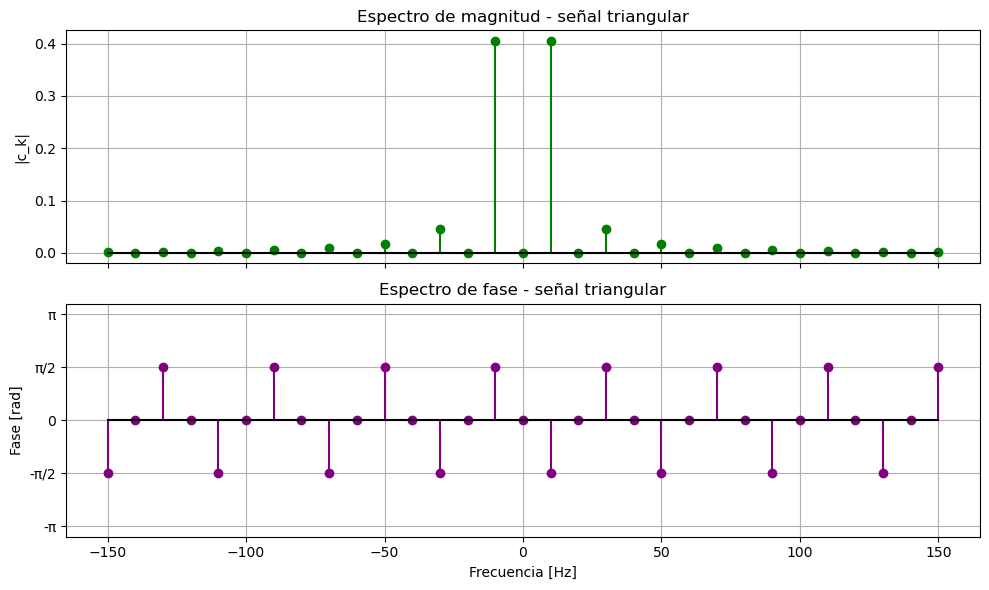

In [26]:
espectros_fourier(c_cuadrada, f0, "señal cuadrada",
                  color_mag="tab:blue", color_fase="tab:orange")
espectros_fourier(c_triangular, f0, "señal triangular",
                  color_mag="green", color_fase="purple")

plt.show()

h - Función que reconstruye una señal a partir de una suma de senos (armónicos), recibiendo 
como parámetros los coeficientes de Fourier y el número de armónicos a utilizar

In [40]:
def reconstruir_fourier(k, c, t, f0, N_armonicos):
    x_recon = np.zeros(len(t), dtype=complex)

    # Seleccionar los armónicos hasta N
    mascara = np.abs(k) <= N_armonicos

    k_sel = k[mascara]
    c_sel = c[mascara]

    # Reconstrucción mediante la serie exponencial
    for ki, ci in zip(k_sel, c_sel):
        x_recon += ci * np.exp(1j * 2 * np.pi * ki * f0 * t)

    return np.real(x_recon)

i - Reconstrucción de la señal cuadrada y triangular, utilizando N = 1, 3, 5, 20 y 50 armónicos - Gráficas de cada reconstrucción junto con la señal original

In [46]:
# Coeficientes para la reconstrucción hasta 50 armónicos
K_ = 50
k_c_, c_cuadrada_ = coeficientes_fourier(x_cuadrada, N_per, K_)
k_t_, c_triangular_ = coeficientes_fourier(x_triangular, N_per, K_)

def graficar_reconst(k, c, t, f0, nombre):

    armonicos = [1, 3, 5, 20, 50]
    fig, axes = plt.subplots(5, 1, figsize=(12, 14))
    for ax, N in zip(axes, armonicos):
        x_recon = reconstruir_fourier(k, c, t, f0, N)

        if nombre == "Cuadrada":
            original = x_cuadrada
        else:
            original = x_triangular

        ax.plot(t, original,'--', label="Original")
        ax.plot(t, x_recon, label=f"{N} armónicos")
        ax.set_ylabel("Amplitud")
        ax.set_title(f"{nombre} - {N} armónicos")
        ax.grid(True)
        ax.legend(loc="upper right", fontsize=8)
    axes[-1].set_xlabel("Tiempo [s]")

    plt.tight_layout()
    plt.show()


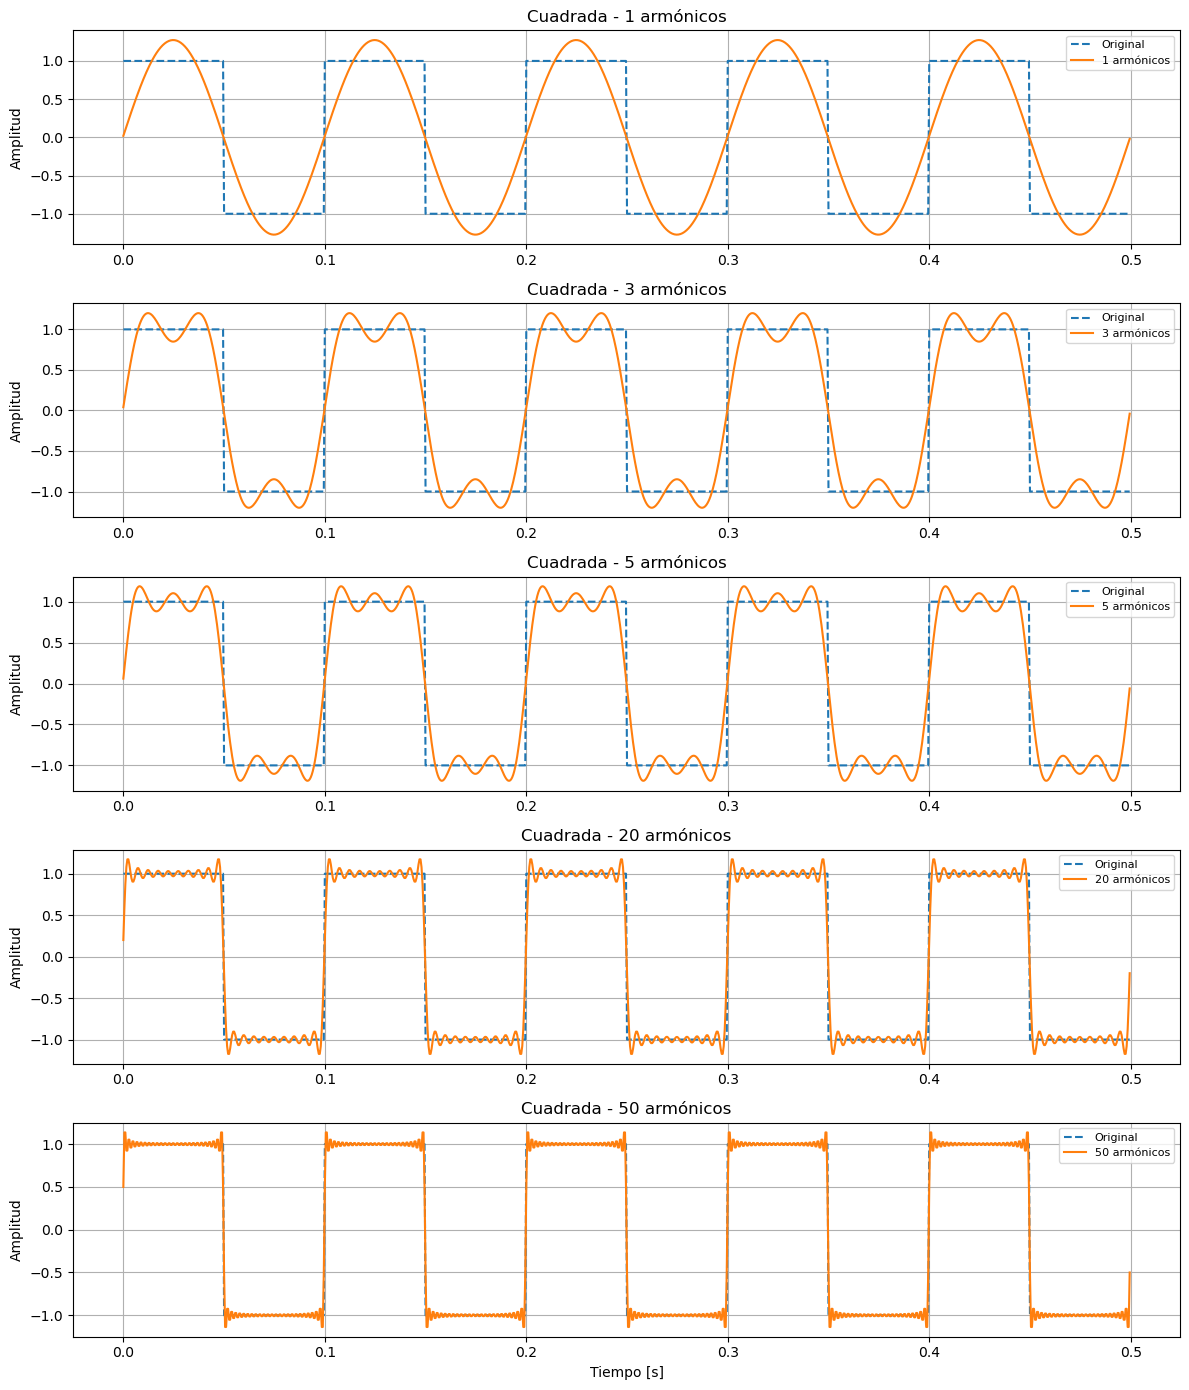

In [47]:
graficar_reconst(k_c_,c_cuadrada_,t,f0,"Cuadrada")

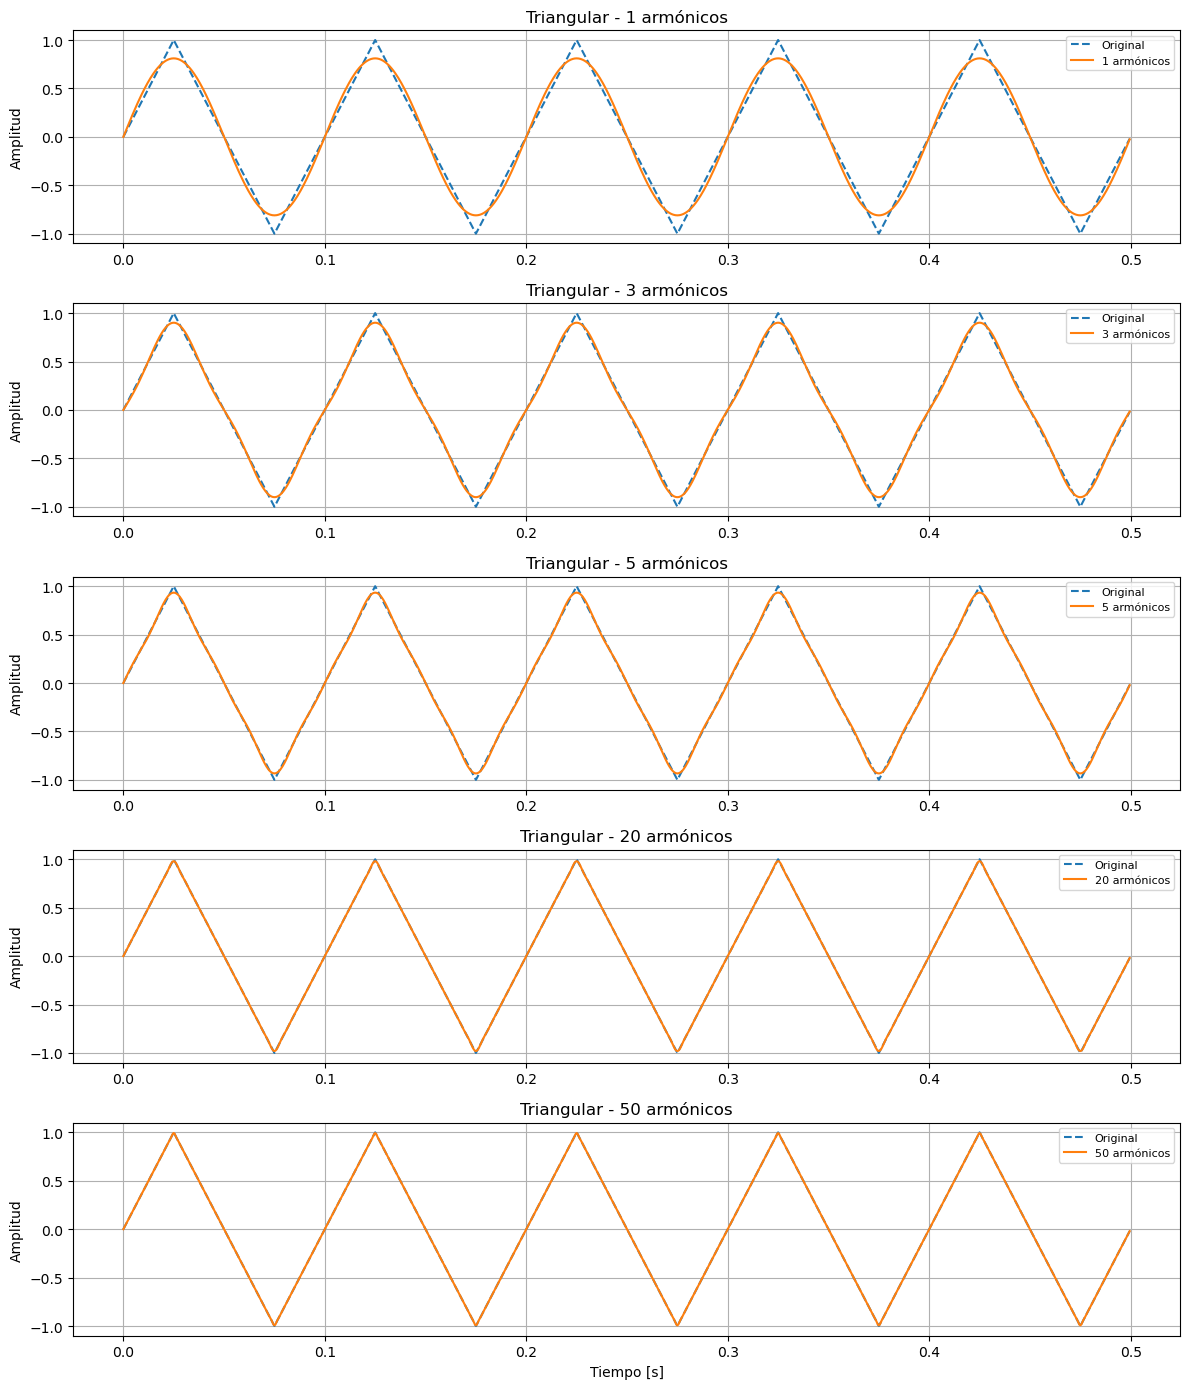

In [48]:
graficar_reconst(k_t_,c_triangular_,t,f0,"Triangular")

j - Descripción del fenómeno de Gibbs observado en las reconstrucciones de la señal 
cuadrada

En las reconstrucciones de la señal cuadrada se observa que, al aumentar el número de armónicos la aproximación se acerca progresivamente a la señal original. Sin embargo, cerca de las discontinuidades aparecen oscilaciones y sobrepicos que no desaparecen completamente, incluso cuando se utilizan 50 armónicos. Este comportamiento corresponde al fenómeno de Gibbs, como se indica en la guía, al utilizar un número finito de armónicos para reconstruir una señal con cambios abruptos, aparecen oscilaciones alrededor de las discontinuidades. Al aumentar el número de armónicos, estas oscilaciones se concentran en una región cada vez más pequeña, pero el sobrepico no desaparece completamente.

k - Carga de una señal ECG sin ruido y con su composición espectral 

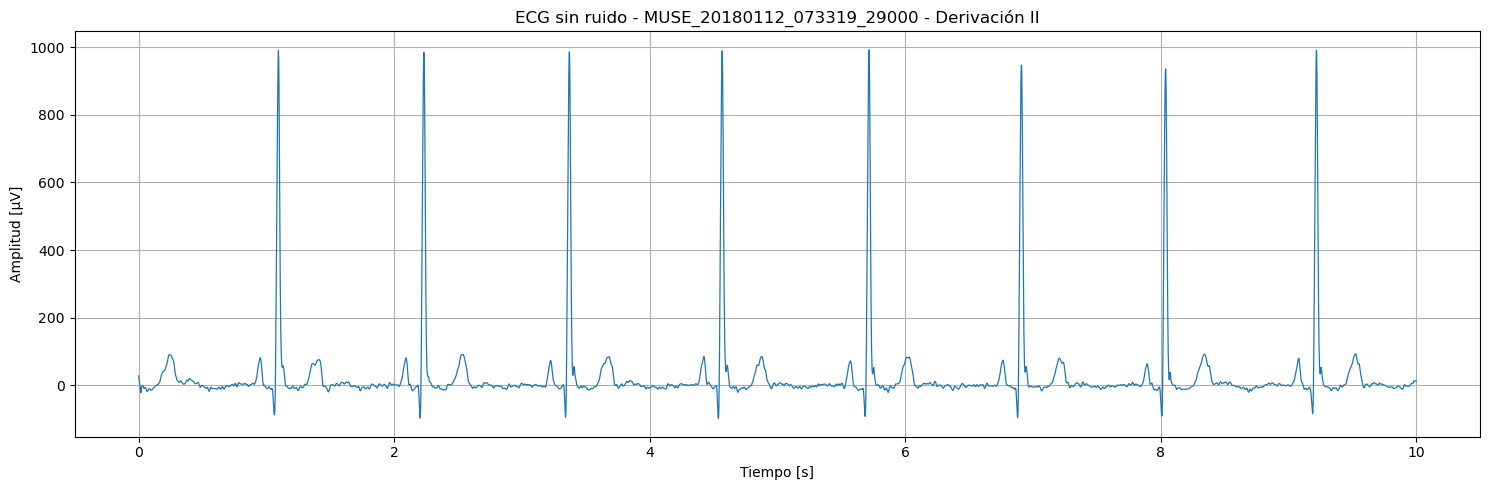

In [59]:
#Cargamos y graficamos la señal de ECG sin ruido tomada de la base de datos de la practica pasada

RUTA_DIAGNOSTICOS =r"C:\Users\corde\OneDrive\Imágenes\Escritorio\Bioseñales\Biosenales-LaurenCordero-AlmaOlea\Practica_2_parte 2\Diagnostics.xlsx"
RUTA_SEÑALES = r"C:\Users\corde\OneDrive\Imágenes\Escritorio\Bioseñales\ECGDataDenoised"

diagnosticos = pd.read_excel(RUTA_DIAGNOSTICOS)
nombres_derivaciones = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                        'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

def cargar_señal(nombre_archivo, ruta=RUTA_SEÑALES):
    ruta_completa = os.path.join(ruta, nombre_archivo + '.csv')
    datos = pd.read_csv(ruta_completa, header=None)
    datos.columns = nombres_derivaciones
    return datos

clase_2 = 'SB'
registro_2 = diagnosticos[diagnosticos['Rhythm'] == clase_2].iloc[0]
señal_2 = cargar_señal(registro_2['FileName'])

fs = 500
lead = 'II'

t = np.arange(señal_2.shape[0]) / fs
señal_ecg = señal_2[lead].values.astype(float)

plt.figure(figsize=(15, 5))
plt.plot(t, señal_ecg, linewidth=0.9)
plt.title(f"ECG sin ruido - {registro_2['FileName']} - Derivación {lead}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [µV]")
plt.grid(True)
plt.tight_layout()
plt.show()

Se seleccionó el registro correspondiente a bradicardia sinusal porque en la derivación II se observa con claridad la morfología P-QRS-T. Esta señal tiene una frecuencia de muestreo de 500 Hz y una duración aproximada de 10 segundos

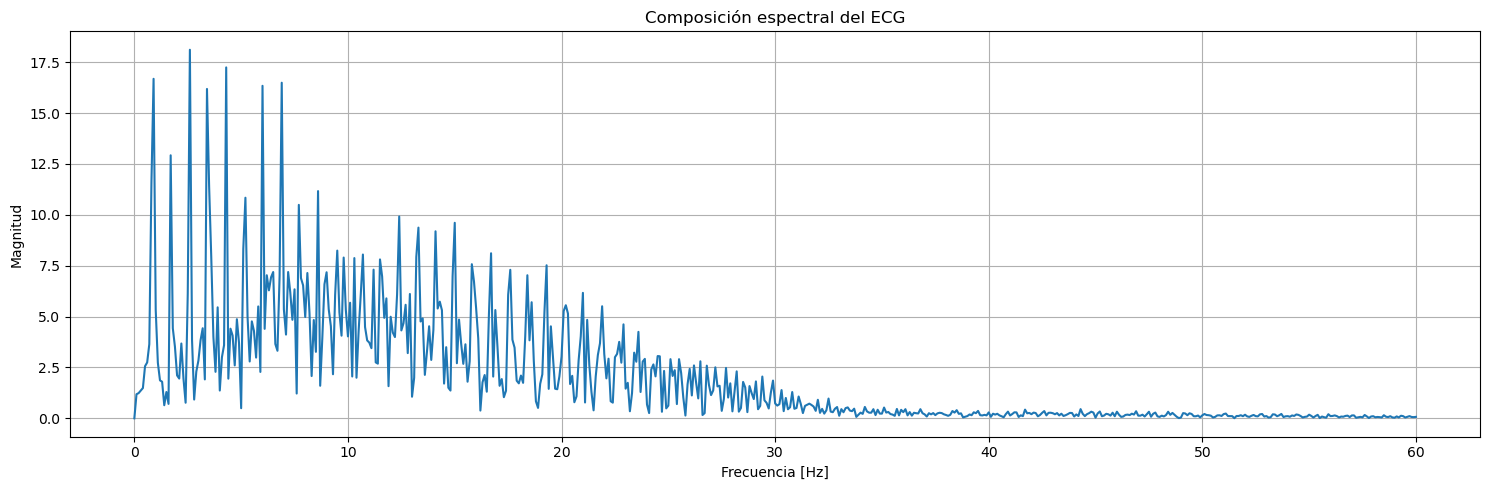

In [62]:
# Eliminación del valor medio para observar mejor
# las componentes oscilatorias del espectro
N = len(señal_ecg)
señal_ecg_centrada = señal_ecg - np.mean(señal_ecg)
# Transformada de Fourier
coeficientes = np.fft.rfft(señal_ecg_centrada)
# Vector de frecuencias
frecuencias = np.fft.rfftfreq(N, d=1/fs)
# Espectro de magnitud
magnitud = np.abs(coeficientes) / N
# Espectro de frecuencias de 0 a 60 Hz
mask_frecuencia = frecuencias <= 60

plt.figure(figsize=(15, 5))
plt.plot(frecuencias[mask_frecuencia],
         magnitud[mask_frecuencia])
plt.title("Composición espectral del ECG")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid(True)
plt.tight_layout()
plt.show()

Para interpretar la composición espectral del ECG se consultaron referencias sobre el contenido frecuencial de sus principales ondas. La literatura reporta que la onda P presenta componentes aproximadamente entre 5 y 30 Hz, el complejo QRS entre 5 y 50 Hz y la onda T principalmente entre 0 y 10 Hz. Estos rangos son aproximados y pueden variar dependiendo de las características de la señal analizada [1][2]

La onda P, relacionada con la despolarización auricular, presenta cambios relativamente lentos, por lo que su contenido se concentra principalmente en las frecuencias bajas. El complejo QRS, relacionado con la despolarización ventricular, presenta cambios mucho más rápidos y pronunciados. Por esta razón, posee un contenido frecuencial más amplio y puede alcanzar frecuencias mayores que las ondas P y T. La literatura indica que una parte importante de la energía del QRS se concentra en las frecuencias bajas y medias, aunque su contenido puede extenderse hasta aproximadamente 50 Hz. Por otro lado, la onda T relacionada con la repolarización ventricular, presenta una variación más lenta y, por tanto, su contenido se encuentra principalmente en las frecuencias bajas, aproximadamente entre 0 y 10 Hz.

En la gráfica obtenida para el ECG se observa que la magnitud del espectro es mayor en las frecuencias bajas y medias y disminuye progresivamente hacia las frecuencias superiores. Esto es consistente con la composición frecuencial esperada del ECG. Las diferentes ondas no corresponden a un único pico de frecuencia, sino que cada una contribuye a un intervalo de frecuencias que puede presentar superposición con las demás.

### Conclusiones 

En la reconstrucción de la señal cuadrada se comprobó que al aumentar el número de armónicos la aproximación se acerca progresivamente a la señal original. Sin embargo, en las discontinuidades permanecen oscilaciones y sobrepicos.

En el análisis del ECG se comprobó que su composición espectral está relacionada con la morfología de sus principales componentes. Las ondas P y T, debido a sus variaciones más lentas, presentan principalmente contenido de baja frecuencia, mientras que el complejo QRS, debido a sus cambios rápidos, presenta un contenido frecuencial más amplio hacia frecuencias medias y altas. El análisis mediante la FFT permitió relacionar la representación temporal del ECG con su composición en frecuencia.

### Referencias 

[1] K. C. Smits, U. C. Nguyen, P. Jurak, K. Curila, J. Halamek, F. Plesinger, and F. W. Prinzen, “Ultra-High-Frequency ECG in Cardiac Pacing and Cardiac Resynchronization Therapy: From Technical Concept to Clinical Application,” Journal of Cardiovascular Development and Disease, vol. 11, no. 3, p. 76, 2024, https://pmc.ncbi.nlm.nih.gov/articles/PMC10970776/ 

[2] L. G. Tereshchenko and M. E. Josephson, “Frequency Content and Characteristics of Ventricular Conduction,” Journal of Electrocardiology, vol. 48, no. 6, pp. 933–937, 2015, https://pmc.ncbi.nlm.nih.gov/articles/PMC4624499/ 